# DRANK (Ruoka) - Project 2

Keyword extraction and evaluation on the ruoka dataset only.

In [1]:
import re
import urllib.request
from collections import Counter

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import nltk
from nltk.stem.snowball import SnowballStemmer
from nltk.tag import pos_tag
from nltk.corpus import stopwords
from bs4 import BeautifulSoup

# NLTK resources
for package in ['punkt', 'averaged_perceptron_tagger', 'universal_tagset', 'stopwords']:
    try:
        nltk.data.find(f'tokenizers/{package}')
    except LookupError:
        nltk.download(package)

sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (10, 5)
print("✓ Libraries ready")

✓ Libraries ready


[nltk_data] Downloading package averaged_perceptron_tagger to
[nltk_data]     /home/muditha/nltk_data...
[nltk_data]   Package averaged_perceptron_tagger is already up-to-
[nltk_data]       date!
[nltk_data] Downloading package universal_tagset to
[nltk_data]     /home/muditha/nltk_data...
[nltk_data]   Package universal_tagset is already up-to-date!
[nltk_data] Downloading package stopwords to
[nltk_data]     /home/muditha/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


In [2]:
# Parameters
base_url = "https://cs.uef.fi/~himat/WebRank/dataset_12/dataset_12/ruoka"
pages_to_scan = 100
keywords_top_k = 10

# Optimization knobs (precision-oriented)
top_tag_n = 10
min_tag_score = 0.20
min_token_count = 2
length_percentile_low = 5
length_percentile_high = 95

# Helpers

def read_url_content(url):
    try:
        with urllib.request.urlopen(url, timeout=8) as response:
            return response.read()
    except Exception:
        return None

def is_visible_text(element):
    if element.parent.name in ["style", "script", "head", "title", "meta", "[document]"]:
        return False
    if element.__class__.__name__ == "Comment":
        return False
    return True

def get_stop_words():
    try:
        return set(stopwords.words('finnish'))
    except Exception:
        return set(stopwords.words('english'))

stop_words = get_stop_words()

try:
    stemmer = SnowballStemmer('finnish')
except Exception:
    stemmer = SnowballStemmer('english')

print("✓ Parameters set")

✓ Parameters set


In [3]:
def fetch_gt_for_page(page_index):
    gt_url = f"{base_url}/{page_index}/GT.txt"
    gt_content = read_url_content(gt_url)
    if not gt_content:
        return []
    gt_text = gt_content.decode("utf-8-sig").strip().lower()
    tokens = gt_text.split()
    return list(set(stemmer.stem(t) for t in tokens))

# Collect GT stems and length stats for filtering
all_gt_stems = []
page_gt_map = {}

for i in range(pages_to_scan):
    gt_stems = fetch_gt_for_page(i)
    if gt_stems:
        page_gt_map[i] = gt_stems
        all_gt_stems.extend(gt_stems)

all_gt_stems = list(set(all_gt_stems))
lengths = [len(stem) for stem in all_gt_stems]

length_min = int(np.percentile(lengths, length_percentile_low))
length_max = int(np.percentile(lengths, length_percentile_high))
length_min = max(2, length_min)
length_max = max(length_min, length_max)

print(f"✓ GT stems: {len(all_gt_stems)}")
print(f"✓ Length filter (p{length_percentile_low}-p{length_percentile_high}): {length_min} to {length_max}")

✓ GT stems: 332
✓ Length filter (p5-p95): 4 to 13


In [4]:
def extract_tag_tokens(html_content):
    soup = BeautifulSoup(html_content, "lxml")
    tag_tokens = {}
    for node in soup.find_all(string=True):
        if not is_visible_text(node):
            continue
        text = node.strip()
        if not text:
            continue
        words = re.findall(r"[A-Za-zÅÄÖåäö]+", text.lower())
        if not words:
            continue
        tag = node.parent.name
        tag_tokens.setdefault(tag, []).extend(words)
    return tag_tokens

def filter_noun_tokens(tokens, length_min, length_max):
    try:
        tagged = pos_tag(tokens, tagset='universal')
    except Exception:
        tagged = [(t, 'UNK') for t in tokens]

    filtered = []
    for tok, pos_name in tagged:
        if tok in stop_words:
            continue
        if len(tok) < length_min or len(tok) > length_max:
            continue
        if pos_name != 'NOUN':
            continue
        filtered.append(tok)
    return filtered

# Tag weights from previous GT analysis

def load_tag_weights(path="gt_tag_summary.csv"):
    try:
        df = pd.read_csv(path)
    except Exception:
        return {}, set()

    df = df.sort_values("score", ascending=False)
    if top_tag_n:
        df = df.head(top_tag_n)
    df = df[df["score"] >= min_tag_score]

    if df.empty:
        return {}, set()

    max_score = df["score"].max()
    weights = dict(zip(df['tag'], df['score'] / max_score))
    allowed_tags = set(weights.keys())
    return weights, allowed_tags


tag_weights, allowed_tags = load_tag_weights()
print(f"✓ Tag weights loaded: {len(tag_weights)}")
print(f"✓ Allowed tags: {sorted(list(allowed_tags))}")

✓ Tag weights loaded: 0
✓ Allowed tags: []


In [5]:
def drank_extract_keywords(page_index, length_min, length_max, top_k=10):
    html_content = read_url_content(f"{base_url}/{page_index}/")
    if not html_content:
        return []

    tag_tokens = extract_tag_tokens(html_content)
    scores = Counter()

    for tag, tokens in tag_tokens.items():
        if not tokens:
            continue
        if allowed_tags and tag not in allowed_tags:
            continue

        filtered = filter_noun_tokens(tokens, length_min, length_max)
        if not filtered:
            continue

        stems = [stemmer.stem(t) for t in filtered]
        freq = Counter(stems)
        tag_weight = tag_weights.get(tag, 1.0)
        tag_len = len(filtered)

        for stem, count in freq.items():
            if count < min_token_count:
                continue
            scores[stem] += (count / tag_len) * tag_weight

    if not scores:
        return []

    ranked = [kw for kw, _ in scores.most_common(top_k)]
    return ranked

# Evaluate

rows = []
all_precision = []
all_recall = []
all_f1 = []

for page_index in range(pages_to_scan):
    gt_stems = page_gt_map.get(page_index, [])
    if not gt_stems:
        continue

    pred = drank_extract_keywords(page_index, length_min, length_max, top_k=keywords_top_k)
    gt_set = set(gt_stems)
    pred_set = set(pred)

    tp = len(gt_set & pred_set)
    precision = tp / len(pred_set) if pred_set else 0.0
    recall = tp / len(gt_set) if gt_set else 0.0
    f1 = (2 * precision * recall / (precision + recall)) if (precision + recall) > 0 else 0.0

    all_precision.append(precision)
    all_recall.append(recall)
    all_f1.append(f1)

    rows.append({
        "page_index": page_index,
        "precision": precision,
        "recall": recall,
        "f1": f1,
        "predicted": ",".join(pred)
    })

results_df = pd.DataFrame(rows)

print("✓ Evaluation complete")
print(f"Pages evaluated: {len(results_df)}")
print(f"Mean Precision: {np.mean(all_precision):.3f}")
print(f"Mean Recall: {np.mean(all_recall):.3f}")
print(f"Mean F1: {np.mean(all_f1):.3f}")

results_df.to_csv("drank_ruoka_results.csv", index=False)
print("Saved: drank_ruoka_results.csv")

✓ Evaluation complete
Pages evaluated: 100
Mean Precision: 0.190
Mean Recall: 0.267
Mean F1: 0.218

✓ Multi-Tag Analysis:
Avg tags per keyword: 1.23
Keywords in multiple tags: 215/996 (21.6%)

Saved: drank_ruoka_results.csv


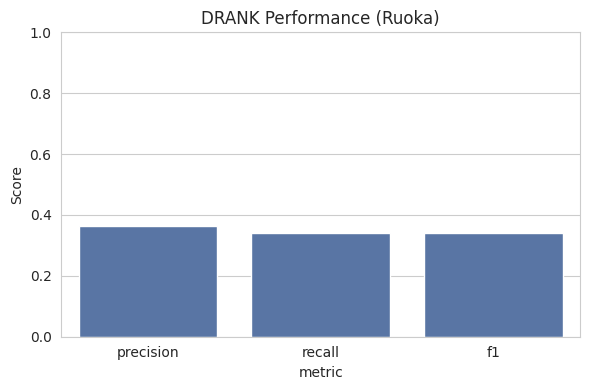

Saved: drank_ruoka_metrics.csv, drank_ruoka_metrics.png


In [16]:
# Summary chart
metrics_df = pd.DataFrame({
    "metric": ["precision", "recall", "f1"],
    "value": [np.mean(all_precision), np.mean(all_recall), np.mean(all_f1)]
})

plt.figure(figsize=(6, 4))
sns.barplot(data=metrics_df, x="metric", y="value", color="#4c72b0")
plt.ylim(0, 1)
plt.title("DRANK Performance (Ruoka)")
plt.ylabel("Score")
plt.tight_layout()
plt.savefig("drank_ruoka_metrics.png", dpi=150, bbox_inches="tight")
plt.show()

# Save summary
metrics_df.to_csv("drank_ruoka_metrics.csv", index=False)
print("Saved: drank_ruoka_metrics.csv, drank_ruoka_metrics.png")